# Classification — Price Category Prediction
Classify laptops as Cheap / Medium / Expensive based on price tertiles.

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('data_features.csv', index_col='ID')

## Price Labels — Tertile Bins

In [2]:
q33, q66 = df['Price'].quantile([0.33, 0.66])
print(f"Cheap  <= {q33:,.0f}")
print(f"Medium  {q33:,.0f} - {q66:,.0f}")
print(f"Expensive > {q66:,.0f}")

label_map = {'Cheap': 0, 'Medium': 1, 'Expensive': 2}
df['price_cat'] = pd.cut(df['Price'], bins=[-np.inf, q33, q66, np.inf],
                          labels=['Cheap', 'Medium', 'Expensive'])
print(df['price_cat'].value_counts().sort_index())

Cheap  <= 38,254
Medium  38,254 - 67,239
Expensive > 67,239
price_cat
Cheap        430
Medium       431
Expensive    442
Name: count, dtype: int64


In [3]:
X = df.drop(columns=['Price', 'log_price', 'price_cat'])
y = df['price_cat'].map(label_map).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}  Test: {X_test.shape}")

Train: (1042, 63)  Test: (261, 63)


## Model Definitions

In [4]:
classifiers = {
    'Logistic Regression': Pipeline([('scaler', StandardScaler()),
                                      ('model', LogisticRegression(C=1.0, max_iter=1000))]),
    'SVM':                 Pipeline([('scaler', StandardScaler()),
                                      ('model', SVC(C=10, kernel='rbf', gamma='scale',
                                                    probability=True))]),
    'Random Forest':       RandomForestClassifier(n_estimators=400, max_features='sqrt',
                                                   min_samples_leaf=2, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=300, learning_rate=0.1,
                                                       max_depth=4, subsample=0.8, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=5,
                                          subsample=0.8, colsample_bytree=0.8,
                                          random_state=42, n_jobs=-1, eval_metric='mlogloss'),
    'LightGBM':            LGBMClassifier(n_estimators=300, learning_rate=0.1, num_leaves=63,
                                           subsample=0.8, colsample_bytree=0.8,
                                           random_state=42, n_jobs=-1, verbose=-1),
}

## Cross-Validation + Test Evaluation

In [5]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, clf in classifiers.items():
    cv_acc = cross_val_score(clf, X_train, y_train, cv=skf, scoring='accuracy').mean()
    cv_f1  = cross_val_score(clf, X_train, y_train, cv=skf, scoring='f1_macro').mean()
    clf.fit(X_train, y_train)
    y_pred   = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    test_f1  = f1_score(y_test, y_pred, average='macro')
    results[name] = {'CV Accuracy': cv_acc, 'CV F1 (macro)': cv_f1,
                     'Test Accuracy': test_acc, 'Test F1 (macro)': test_f1}

results_df = pd.DataFrame(results).T.sort_values('Test Accuracy', ascending=False)
results_df

,CV Accuracy,CV F1 (macro),Test Accuracy,Test F1 (macro)
Gradient Boosting,0.826279,0.826660,0.869732,0.868904
Random Forest,0.813765,0.814456,0.858238,0.858289
XGBoost,0.823385,0.823940,0.858238,0.857895
LightGBM,0.824356,0.824604,0.858238,0.858283
SVM,0.817621,0.818993,0.831418,0.831717
Logistic Regression,0.810867,0.812687,0.816092,0.817495


## Best Model — Classification Report

In [6]:
best_name = results_df.index[0]
best_clf  = classifiers[best_name]
print(f"Best model: {best_name}")
print()
print(classification_report(y_test, best_clf.predict(X_test),
                             target_names=['Cheap', 'Medium', 'Expensive']))

Best model: Gradient Boosting

              precision    recall  f1-score   support

       Cheap       0.92      0.90      0.91        86
      Medium       0.83      0.79      0.81        86
   Expensive       0.86      0.92      0.89        89

    accuracy                           0.87       261
   macro avg       0.87      0.87      0.87       261
weighted avg       0.87      0.87      0.87       261



## Confusion Matrix

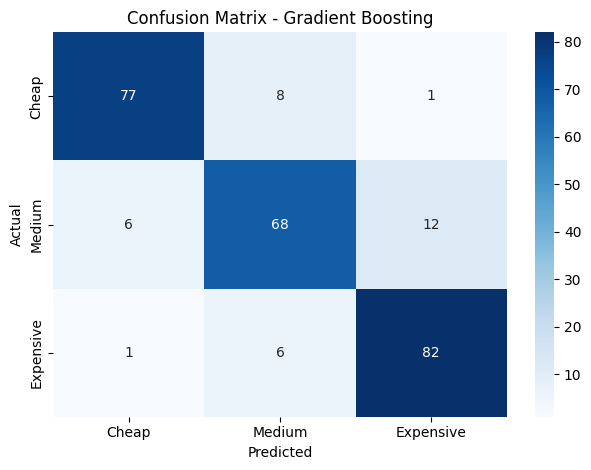

In [7]:
cm = confusion_matrix(y_test, best_clf.predict(X_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cheap', 'Medium', 'Expensive'],
            yticklabels=['Cheap', 'Medium', 'Expensive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_name}')
plt.tight_layout()
plt.show()

## Feature Importance — LightGBM

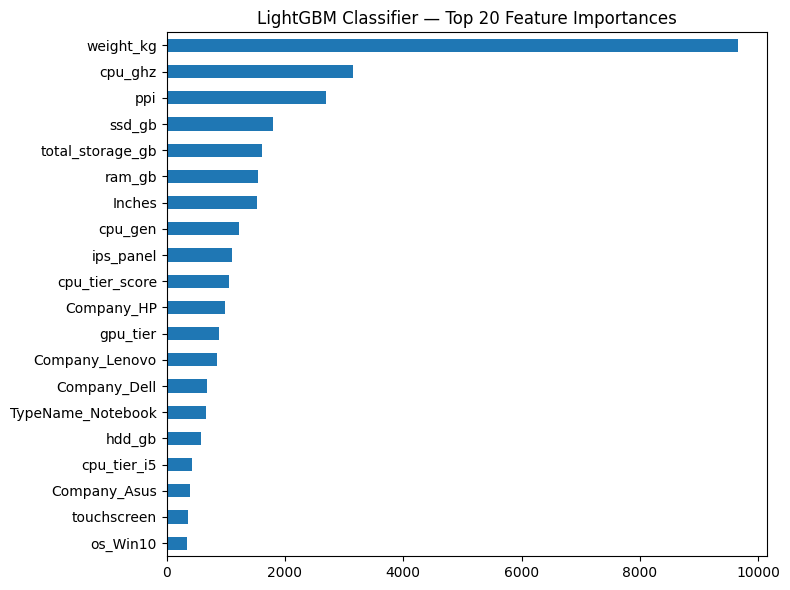

In [8]:
lgbm_clf = classifiers['LightGBM']
fi = pd.Series(lgbm_clf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
fi.plot(kind='barh', figsize=(8, 6), title='LightGBM Classifier — Top 20 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()